**Mickey Zhang**

Spring 2026

CS 251 / 252: Data Analysis and Visualization

Project 5: Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pca

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5, legacy='1.25')

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

## Task 3: Analyzing the results of PCA

In this task, you will apply PCA to the Iris dataset and analyze properties of the PCA representation.

### 3a. Import Iris data

In the cell below:
- load in the Iris dataset into a pandas DataFrame.
- select all numeric headers (i.e. drop `species`).
- Print out the head (only showing the first 5 data samples).

You should see (with better formatting):

```
	sepal_length	sepal_width	petal_length	petal_width
0	5.1	3.5	1.4	0.2
1	4.9	3.0	1.4	0.2
2	4.7	3.2	1.3	0.2
3	4.6	3.1	1.5	0.2
4	5.0	3.6	1.4	0.2
```

In [3]:
# YOUR CODE HERE

iris_data = pd.read_csv("data/iris.csv")
iris_numeric = iris_data.drop(columns=['species'])
print(iris_numeric.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


### 3b. Apply PCA to Iris

You should make the following plots:
1. Elbow plot of cumulative variance accounted for by first $k$ principal components.
2. Written description of your choice of number of PCs preserved and why.
3. Visualization (plot) of PCA projected data on 1st two PCs.

You should normalize the dataset when performing your PCA projection.

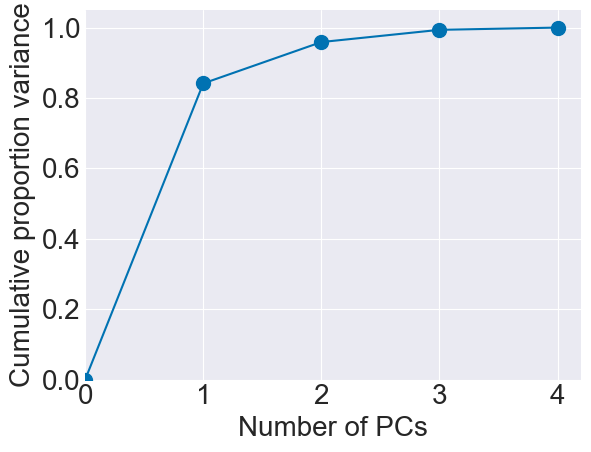

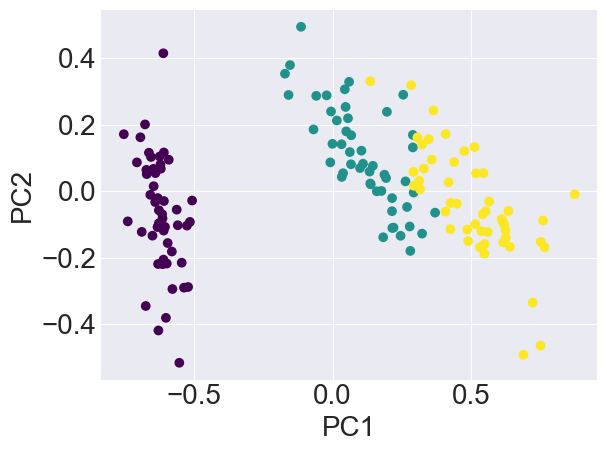

In [9]:
# YOUR CODE HERE

iris_pca = pca.PCA(iris_numeric)
iris_headers = list(iris_numeric.columns)
iris_pca.fit(iris_headers, normalize_dataset=True)

iris_pca.elbow_plot()
plt.show()
plt.figure()

A_proj = iris_pca.pca_project([0, 1])
plt.scatter(A_proj[:, 0], A_proj[:, 1], c=pd.factorize(iris_data['species'])[0], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### 3c. Dropping different pairs of principal components

In the cell below, create a "high quality" 2x2 subplots grid of scatter plots that drops different consecutive PCs from the data, then project onto the remaining PCs.

The 2x2 plots should keep:
- (top-left) PCs [3, 4]
- (top-right) PCs [2, 3]
- (bottom-left) PCs [4, 1]
- (bottom-right) PCs [1, 2]

High quality means
- x and y axis label indicating the PC (e.g. PC1)
- title indicating the PCs shown in the plot

You may have to adjust the font/figure sizes to make things legible.

<Figure size 640x480 with 0 Axes>

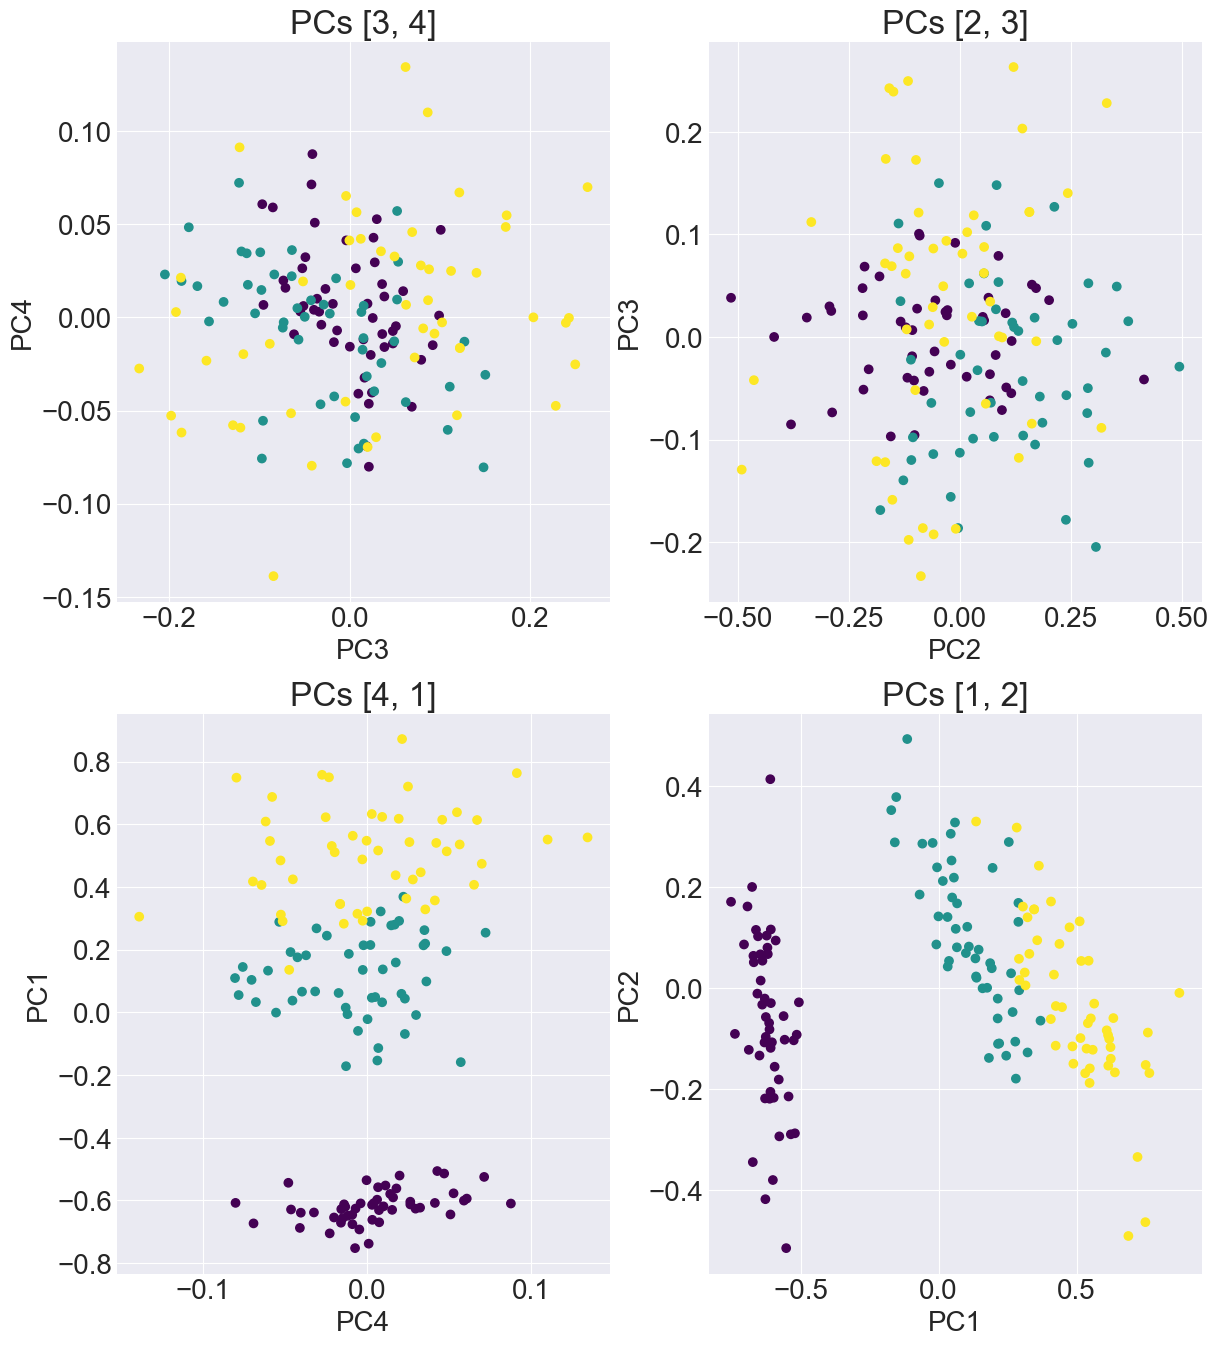

In [15]:
# YOUR CODE HERE
plt.figure()
fig, axes = plt.subplots(2, 2, figsize=(14, 16))

pc_pairs = [[2, 3], [1,2], [3,0], [0,1]]
colors = pd.factorize(iris_data['species'])[0]

for ax, pcs in zip(axes.flatten(), pc_pairs):
    A_proj = iris_pca.pca_project(pcs)
    ax.scatter(A_proj[:, 0], A_proj[:, 1], c=colors, cmap='viridis')
    ax.set_xlabel(f"PC{pcs[0] + 1}")
    ax.set_ylabel(f"PC{pcs[1] + 1}")
    ax.set_title(f"PCs [{pcs[0]+1}, {pcs[1] + 1}]")

plt.show()


### 3d. Questions

**Question 8:** Based on your plot, how does keeping different PCs affect the visible structure of the data? **Please be specific.**

**Answer 8:** 

YOUR ANSWER HERE

We can clearly see that, along with our elbow plot, that keeping PC's 1 and 2 maintain the most visible structure because they together can contribute upwards of 90%+ of the variance in our data. PC1 has the highest variance of teh 4 combined, which makes sense why the graph of PC1 and PC4 has more structure than that of PC2 and PC3. The higher the variance, the more obvious the structure

### 3e. Reconstruct data based on PCs

In `pca_cov.py`, implement `pca_then_project_back`, which projects the data to PCA space, keeping only the top $k$ PCs, then projects from PCA space back onto the original data space. Then in the cell below, create a scatter plot of the two data variables `sepal_length` (x), `sepal_width` (y) of the Iris data **without any normalization**.

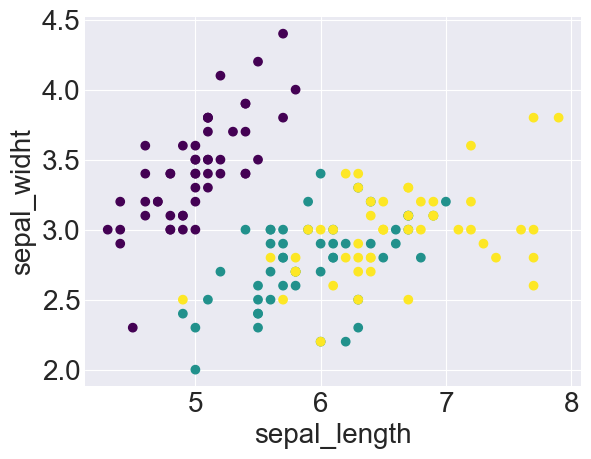

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:
# YOUR CODE HERE

plt.figure()

plt.scatter(iris_numeric["sepal_length"], iris_numeric["sepal_width"], c=colors, cmap="viridis")
plt.xlabel("sepal_length")
plt.ylabel("sepal_widht")
plt.show()
plt.figure()



In the cell below, apply PCA on the Iris dataset **without any normalization** and create a 2x2 grid of scatter plots showing the data reconstruction of the 1st two data variables (`sepal_length`, `sepal_width` — *these are what your axis labels should be*) when keeping the top 1, 2, 3, or 4 (all) principal components.

If everything goes well, if you keep all 4 PCs you should get the original dataset back (it should match your `sepal_length`, `sepal_width` plot created one cell above — including the data range and center).

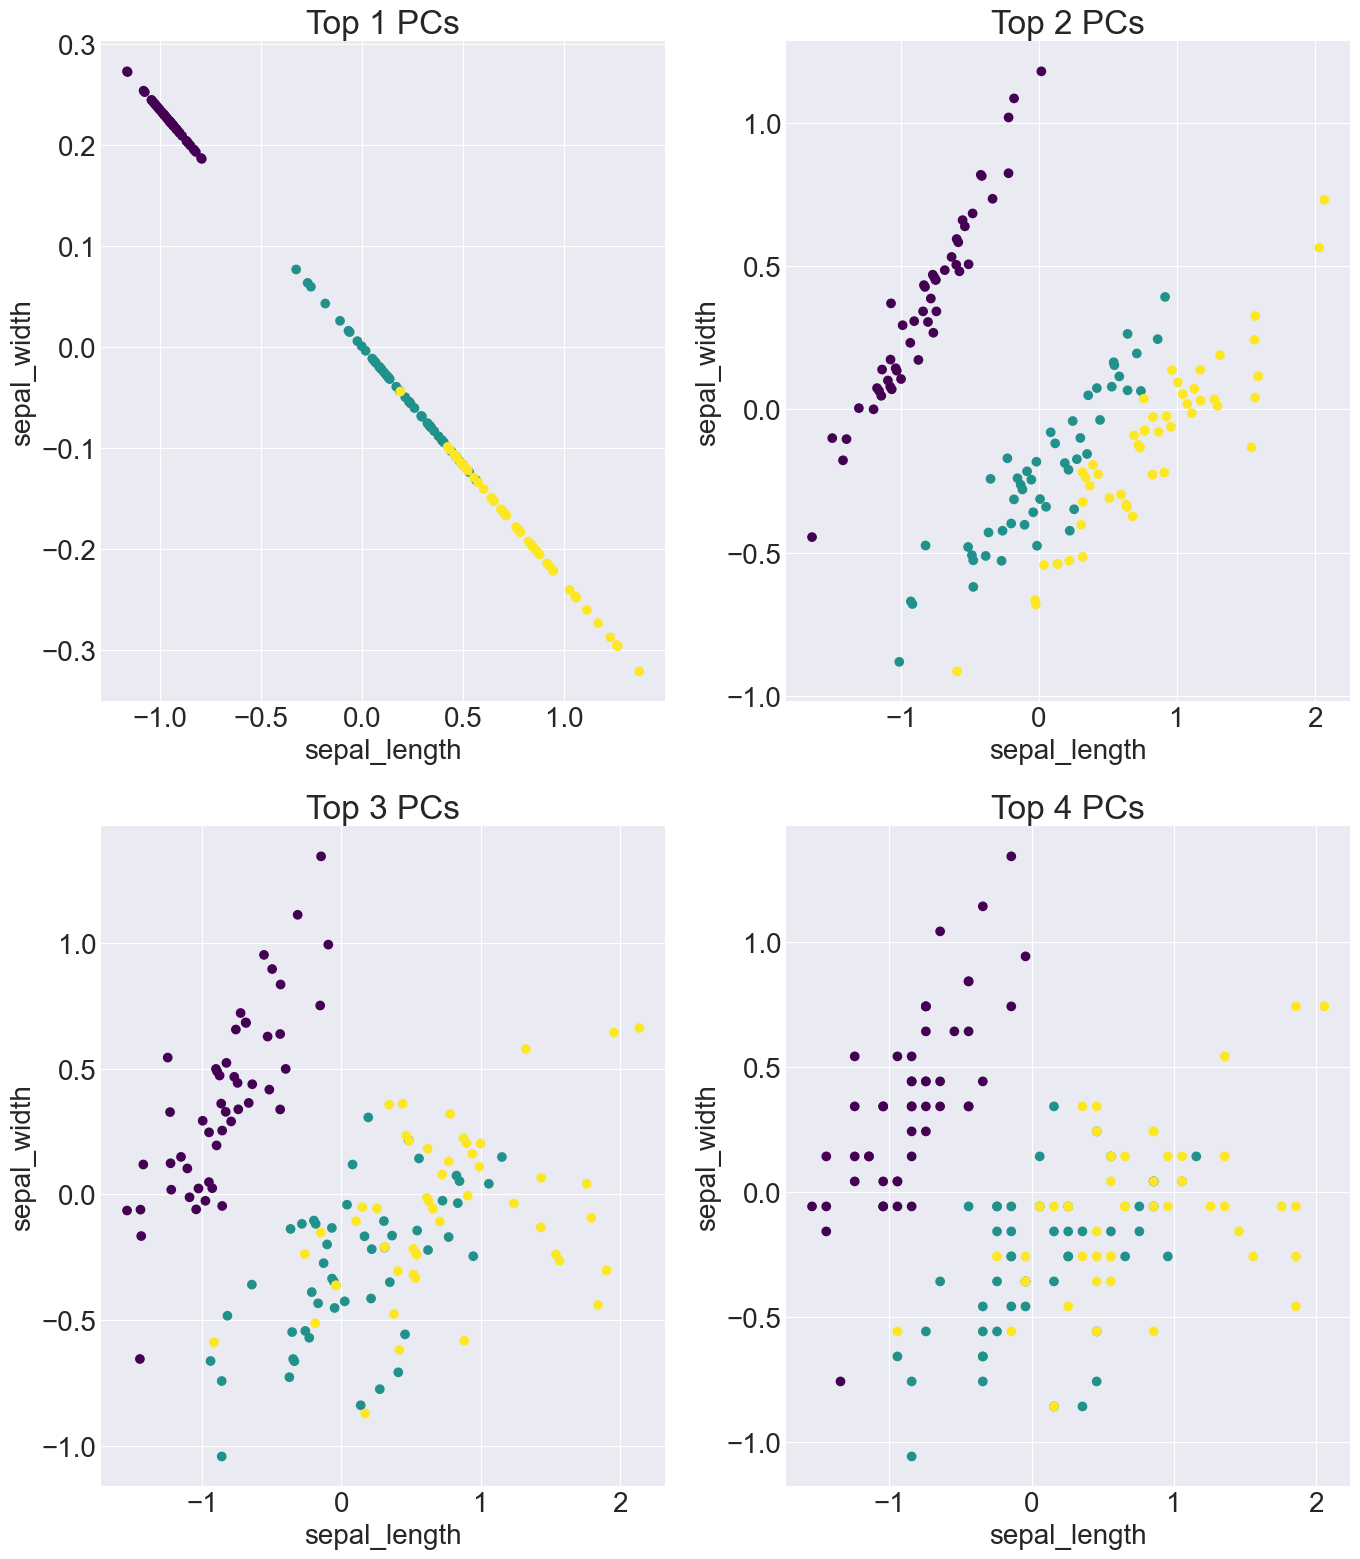

In [17]:
# YOUR CODE HERE
iris_pca.fit(iris_headers, normalize_dataset=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 16))

for ax, k in zip(axes.flatten(), [1, 2, 3, 4]):
    A_back = iris_pca.pca_then_project_back(k)
    ax.scatter(A_back[:, 0], A_back[:, 1], c=colors, cmap='viridis')
    ax.set_xlabel('sepal_length')
    ax.set_ylabel('sepal_width')
    ax.set_title(f'Top {k} PCs')

plt.tight_layout()
plt.show()

### 3f. Questions

**Question 9:**

(a) How many PCs are necessary to capture the two distinct clusters in the samples with respect to their sepal length and width?

(b) How well do each number of PCs reconstruct the original plot from Task 3e showing the relationship between sepal length and width?

**Answer 9:** 

a) 2PCs as 1 is literally a straight line and 3 things start getting clutterred. 2 perfectly captures the break point for distinct figures.

b) 1 PC is pretty bad as it collapses everything into a linear line, 2 PCs better we see clearly defined structure, 3 PCs very close to original, 4 PCs is identicial the original

### 3g. Implement loading plot

To visualize how the top two principal components relate to original data variables, implement `loading_plot` in `pca.py`.

### 3h. Questions

**Question 10:** Call your `loading_plot` method to generate a loading plot of the Iris dataset. What do the loadings tell us what the first two PCs measure specifically, with respect to the original data variables?

**Answer 10:** 

YOUR ANSWER HERE

The first two PC's are mostly measuring petal_legnth and petal_wdith along PC1 and sepal widht along PC2. With sepal_length contributing towards both of the PC's

**Question 11:** What specific correlations among original data variables do the loadings help us identity?

**Answer 11:**

YOUR ANSWER HERE
the vector for petal_length and petal_width are almost identical, which means they must be highly correlated and they contribute alot towards PC1

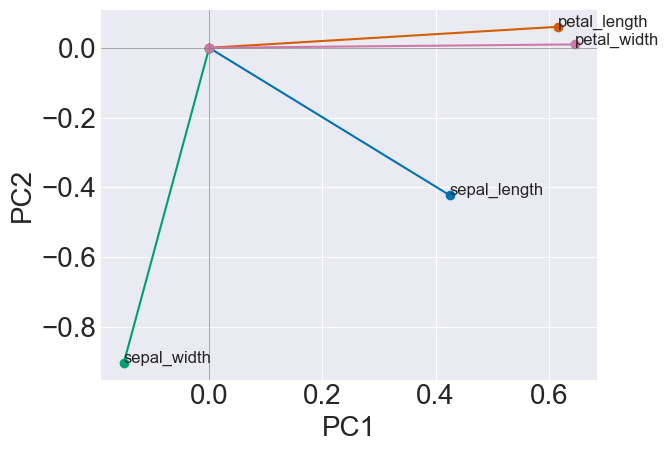

In [19]:
# YOUR CODE HERE
iris_pca.fit(iris_headers, normalize_dataset=True)
iris_pca.loading_plot()
plt.show()